In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [11]:
import os
import gc
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, accuracy_score
from tqdm.auto import tqdm

In [2]:
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.9.0+cpu
CUDA available  : False


In [23]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

# ── Config — tweak these to experiment ───────────────────────────────────────
CFG = {
    # Paths (Kaggle default input path)
    'train_path': '/kaggle/input/datasets/ericazhang0127/llm-classification-finetuning/train.csv',
    'test_path':  '/kaggle/input/datasets/ericazhang0127/llm-classification-finetuning/test.csv',
    'sub_path':   '/kaggle/input/datasets/ericazhang0127/llm-classification-finetuning/sample_submission.csv',

    # Model
    'model_name': '/kaggle/input/models/phmngc/microsoftdeberta-v3-large/transformers/default/1',   # swap to deberta-v3-large for +score
    'num_labels': 3,

    # Tokenisation
    'max_length': 2000,       # increase to 1024+ if GPU allows
    'truncation_side': 'right',

    # Training
    'num_folds':       5,
    'train_folds':     [0, 1, 2],   # train on first 3 folds to save time
    'epochs':          3,
    'batch_size':      8,
    'grad_accum':      4,            # effective batch = 8*4 = 32
    'lr':              2e-5,
    'warmup_ratio':    0.1,
    'weight_decay':    0.01,
    'fp16':            torch.cuda.is_available(),

    # Labels
    'label2id': {'winner_model_a': 0, 'winner_model_b': 1, 'tie': 2},
    'id2label': {0: 'winner_model_a', 1: 'winner_model_b', 2: 'tie'},
}

print("Config loaded ✓")

Config loaded ✓


2. **Load & Explore Data**

In [5]:
train_df = pd.read_csv(CFG['train_path'])
test_df  = pd.read_csv(CFG['test_path'])

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
train_df.head(3)

Train shape : (57477, 9)
Test shape  : (3, 4)


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1


In [6]:
# ── Create a single target column from the three binary winner columns ────────
def get_label(row):
    if row['winner_model_a'] == 1:
        return 'winner_model_a'
    elif row['winner_model_b'] == 1:
        return 'winner_model_b'
    else:
        return 'tie'

train_df['label']    = train_df.apply(get_label, axis=1)
train_df['label_id'] = train_df['label'].map(CFG['label2id'])

print("Label distribution:")
print(train_df['label'].value_counts(normalize=True).round(3))

Label distribution:
label
winner_model_a    0.349
winner_model_b    0.342
tie               0.309
Name: proportion, dtype: float64


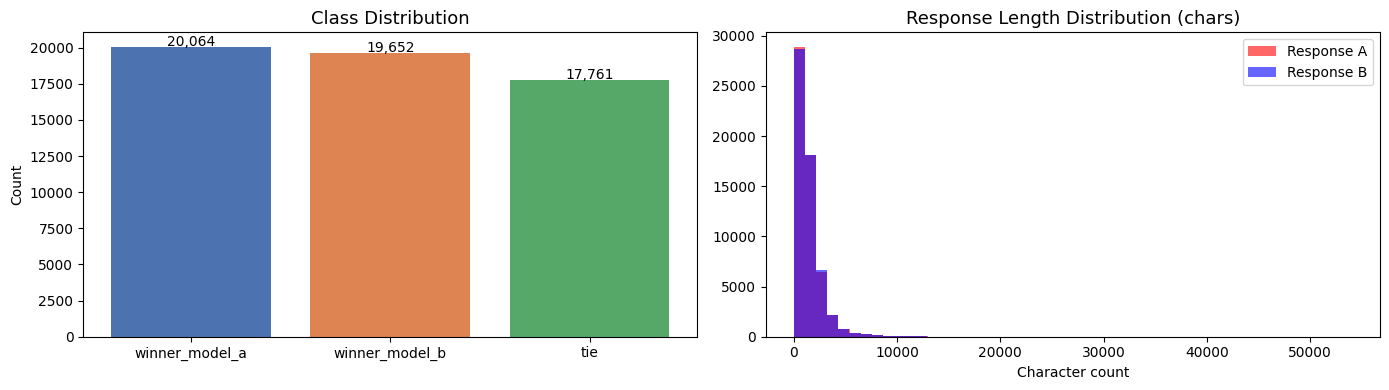


💡 Note: If classes are imbalanced, consider class weights in your loss function.


In [7]:
# ── Visualise class balance ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
counts = train_df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# Response length distribution
train_df['resp_a_len'] = train_df['response_a'].fillna('').apply(len)
train_df['resp_b_len'] = train_df['response_b'].fillna('').apply(len)
axes[1].hist(train_df['resp_a_len'], bins=50, alpha=0.6, label='Response A', color= 'red')
axes[1].hist(train_df['resp_b_len'], bins=50, alpha=0.6, label='Response B', color='blue')
axes[1].set_title('Response Length Distribution (chars)', fontsize=13)
axes[1].set_xlabel('Character count')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n💡 Note: If classes are imbalanced, consider class weights in your loss function.")

In [8]:
# ── Check for nulls ───────────────────────────────────────────────────────────
print("Null counts in train:")
print(train_df[['prompt','response_a','response_b']].isnull().sum())

Null counts in train:
prompt        0
response_a    0
response_b    0
dtype: int64


**3. Preprocessing & Prompt Engineering** 

In [9]:
# ── Input template — easy to swap out and experiment ─────────────────────────
def build_input_text(row):
    """
    Combine prompt + both responses into a single string.
    The [SEP] tokens help DeBERTa understand boundaries.
    """
    prompt     = str(row['prompt'])     if pd.notna(row['prompt'])     else ''
    response_a = str(row['response_a']) if pd.notna(row['response_a']) else ''
    response_b = str(row['response_b']) if pd.notna(row['response_b']) else ''

    # Template v1 — straightforward
    text = (
        f"[PROMPT] {prompt} "
        f"[RESPONSE A] {response_a} "
        f"[RESPONSE B] {response_b}"
    )
    return text

    # ── Uncomment to try Template v2 (question-style framing) ──────────────
    # text = (
    #     f"Which response is better?\n"
    #     f"Prompt: {prompt}\n"
    #     f"Response A: {response_a}\n"
    #     f"Response B: {response_b}"
    # )
    # return text

train_df['input_text'] = train_df.apply(build_input_text, axis=1)
test_df['input_text']  = test_df.apply(build_input_text, axis=1)

# Preview
print("Example input text (truncated):")
print(train_df['input_text'].iloc[0][:400], '...')

Example input text (truncated):
[PROMPT] ["Is it morally right to try to have a certain percentage of females on managerial positions?","OK, does pineapple belong on a pizza? Relax and give me fun answer."] [RESPONSE A] ["The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity, and discr ...


In [24]:
# ── Check tokenised length distribution ──────────────────────────────────────
# This helps you pick a good max_length without wasting memory
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])

sample_lengths = train_df['input_text'].sample(500, random_state=SEED).apply(
    lambda x: len(tokenizer.encode(x, truncation=False))
)

print(f"Token length stats (sample of 500):")
print(sample_lengths.describe().astype(int))
print(f"\n% under 512 tokens  : {(sample_lengths <= 512).mean():.1%}")
print(f"% under 1024 tokens : {(sample_lengths <= 1024).mean():.1%}")
print(f"\n💡 Set CFG['max_length'] to cover ~90% of samples if GPU memory allows.")

The tokenizer you are loading from '/kaggle/input/models/phmngc/microsoftdeberta-v3-large/transformers/default/1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Token length stats (sample of 500):
count     500
mean      815
std       771
min        37
25%       310
50%       635
75%       982
max      6806
Name: input_text, dtype: int64

% under 512 tokens  : 41.6%
% under 1024 tokens : 76.2%

💡 Set CFG['max_length'] to cover ~90% of samples if GPU memory allows.


In [25]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class ChatbotArenaDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=512):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding=False,          # handled by DataCollator
            truncation=True,
            return_tensors=None,
        )
        item = {
            'input_ids':      encoding['input_ids'],
            'attention_mask': encoding['attention_mask'],
        }
        if self.labels is not None:
            item['labels'] = self.labels[idx]
        return item

print("Dataset class defined ✓")

Dataset class defined ✓


## 4. Baseline Model — DeBERTa Finetuning ##

In [27]:
# ── Metric function for Trainer ───────────────────────────────────────────────
from sklearn.metrics import log_loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs    = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds    = np.argmax(probs, axis=1)
    acc      = accuracy_score(labels, preds)
    # Competition metric is log loss
    loss     = log_loss(labels, probs)
    return {'log_loss': loss, 'accuracy': acc}

In [ ]:
# ── K-Fold Training Loop ──────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=CFG['num_folds'], shuffle=True, random_state=SEED)
oof_preds = np.zeros((len(train_df), CFG['num_labels']))
test_preds = []

texts  = train_df['input_text'].tolist()
labels = train_df['label_id'].tolist()

for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels)):
    if fold not in CFG['train_folds']:
        print(f"⏭  Skipping fold {fold}")
        continue

    print(f"\n{'='*60}")
    print(f"   FOLD {fold}  |  train={len(train_idx):,}  val={len(val_idx):,}")
    print(f"{'='*60}")

    # ── Tokenizer & Datasets ─────────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])

    train_dataset = ChatbotArenaDataset(
        [texts[i] for i in train_idx],
        [labels[i] for i in train_idx],
        tokenizer, CFG['max_length']
    )
    val_dataset = ChatbotArenaDataset(
        [texts[i] for i in val_idx],
        [labels[i] for i in val_idx],
        tokenizer, CFG['max_length']
    )
    test_dataset = ChatbotArenaDataset(
        test_df['input_text'].tolist(),
        labels=None,
        tokenizer=tokenizer,
        max_length=CFG['max_length']
    )

    # ── Model ────────────────────────────────────────────────────────────────
    model = AutoModelForSequenceClassification.from_pretrained(
        CFG['model_name'],
        num_labels=CFG['num_labels'],
        id2label=CFG['id2label'],
        label2id=CFG['label2id'],
        ignore_mismatched_sizes=True,
    )

    # ── Training Arguments ───────────────────────────────────────────────────
    output_dir = f'./fold_{fold}'
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=CFG['epochs'],
        per_device_train_batch_size=CFG['batch_size'],
        per_device_eval_batch_size=CFG['batch_size'] * 2,
        gradient_accumulation_steps=CFG['grad_accum'],
        learning_rate=CFG['lr'],
        warmup_ratio=CFG['warmup_ratio'],
        weight_decay=CFG['weight_decay'],
        fp16=CFG['fp16'],
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='log_loss',
        greater_is_better=False,       # lower log_loss = better
        logging_steps=50,
        report_to='none',              # set to 'wandb' if you want tracking
        seed=SEED,
    )

    # ── Trainer ──────────────────────────────────────────────────────────────
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    # ── OOF predictions ──────────────────────────────────────────────────────
    val_logits  = trainer.predict(val_dataset).predictions
    val_probs   = torch.softmax(torch.tensor(val_logits), dim=-1).numpy()
    oof_preds[val_idx] = val_probs

    fold_loss = log_loss([labels[i] for i in val_idx], val_probs)
    print(f"\n Fold {fold} OOF log-loss: {fold_loss:.4f}")

    # ── Test predictions for this fold ───────────────────────────────────────
    test_logits = trainer.predict(test_dataset).predictions
    test_probs  = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
    test_preds.append(test_probs)

    # Free GPU memory between folds
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

print("\n Training complete!")


   FOLD 0  |  train=45,981  val=11,496


The tokenizer you are loading from '/kaggle/input/models/phmngc/microsoftdeberta-v3-large/transformers/default/1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: /kaggle/input/models/phmngc/microsoftdeberta-v3-large/transformers/default/1
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias             